In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import muon as mu
import anndata as ad
import nichepca as npc
import scipy.sparse as sparse

import os
import sys
from pathlib import Path

# Add the src directory to the path if it's not already there
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'src':
    sys.path.append(".")  # Add current directory
else:
    sys.path.append(str(notebook_dir / "src"))  # Add src directory

from config import H5AD_DIR, get_h5ad_path

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [14]:
ad_sp = sc.read_h5ad(get_h5ad_path("c_sp_ad.h5ad"))

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


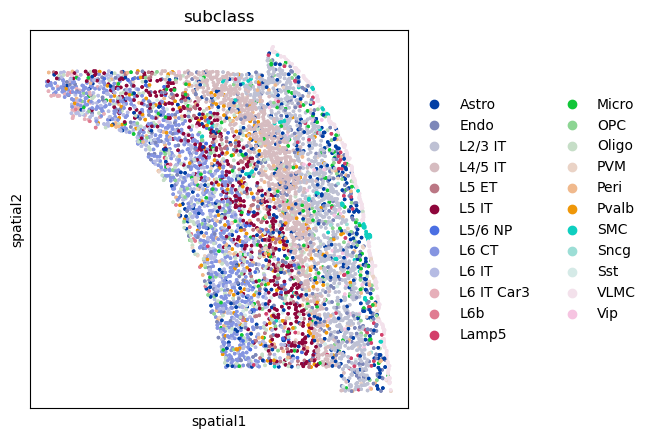

In [30]:
sq.pl.spatial_scatter(
    ad_sp, shape=None, color="subclass", size=10
)

In [16]:
sc.tl.pca(ad_sp)

In [17]:
ad_sp

AnnData object with n_obs × n_vars = 5274 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'

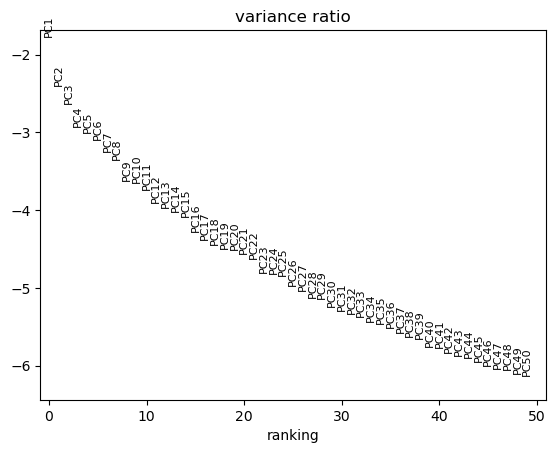

In [18]:
sc.pl.pca_variance_ratio(ad_sp, n_pcs=50, log=True)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


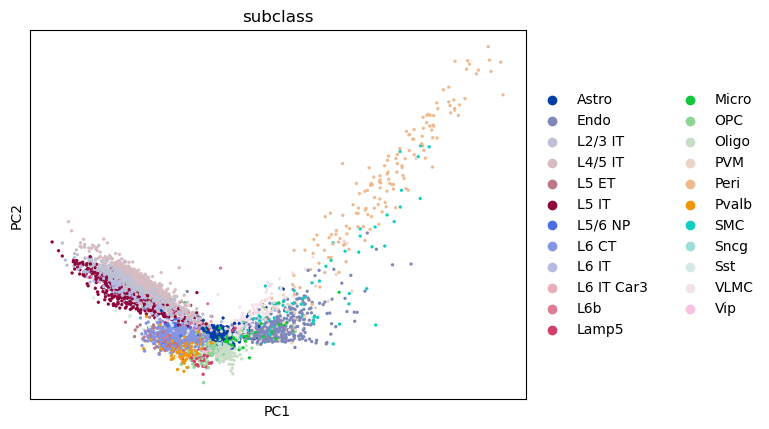

In [21]:
sc.pl.pca(
    ad_sp, color="subclass"
)

In [23]:
# nearest neighbor graph
sc.pp.neighbors(ad_sp, n_pcs=50)
nn_graph_genes = ad_sp.obsp["connectivities"]
# spatial proximity graph
sq.gr.spatial_neighbors(ad_sp)
nn_graph_space = ad_sp.obsp["spatial_connectivities"]

In [24]:
alpha = 0.2

joint_graph = (1 - alpha) * nn_graph_genes + alpha * nn_graph_space
sc.tl.leiden(ad_sp, adjacency=joint_graph, key_added="squidpy_domains")

In [25]:
ad_sp

AnnData object with n_obs × n_vars = 5274 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'squidpy_domains'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'pca', 'subclass_colors', 'neighbors', 'spatial_neighbors', 'leiden'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


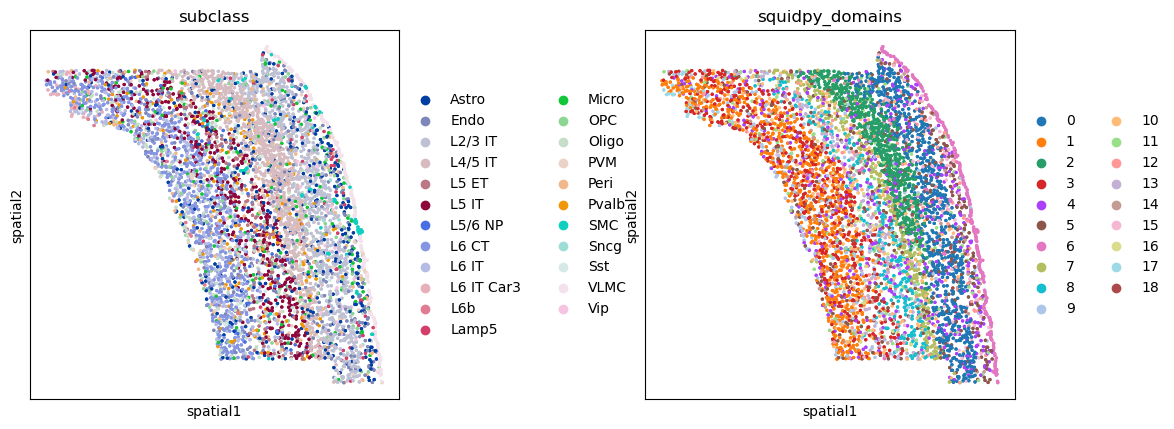

In [37]:
sq.pl.spatial_scatter(ad_sp, shape=None, color=["subclass", "squidpy_domains"], size=8)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


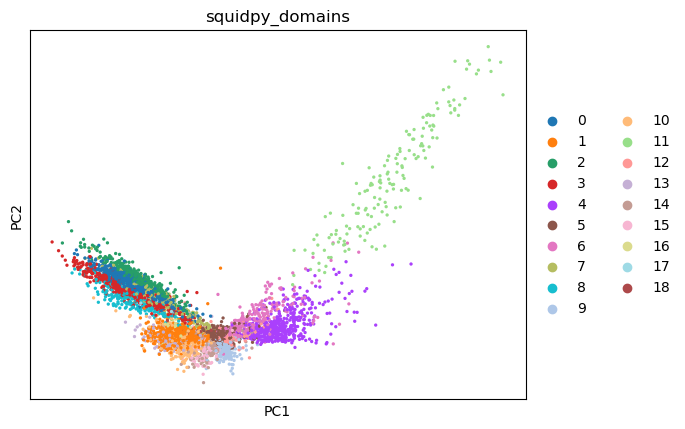

In [39]:
sc.pl.pca(
    ad_sp, color="squidpy_domains"
)

In [41]:
# Run Leiden clustering to identify spatial domains
sc.tl.leiden(ad_sp, resolution=0.5)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


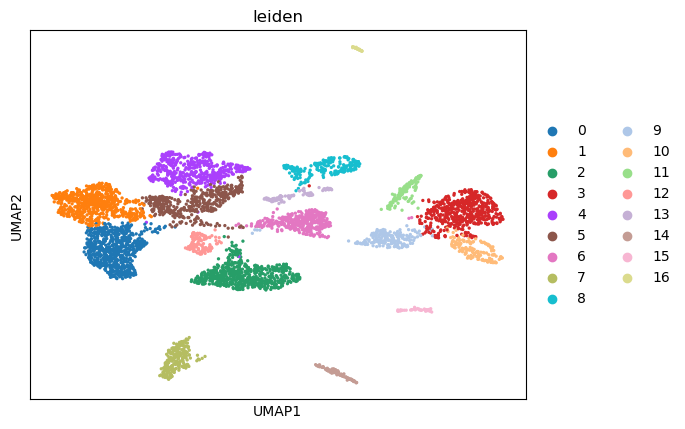

In [42]:
# UMAP visualization of the nichePCA embedding
sc.tl.umap(ad_sp)
sc.pl.umap(ad_sp, color="leiden")

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


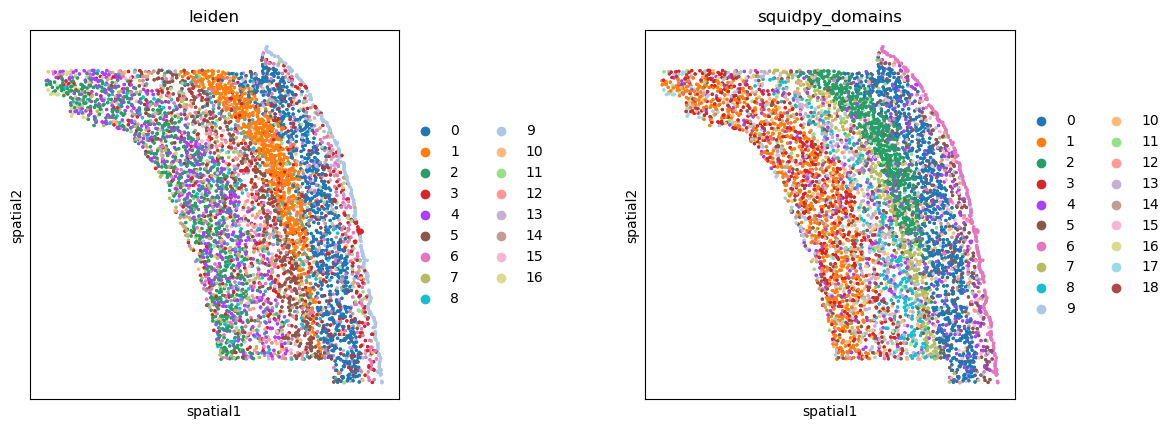

In [43]:
sq.pl.spatial_scatter(ad_sp, shape=None, color=["leiden", "squidpy_domains"], size=8)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = 

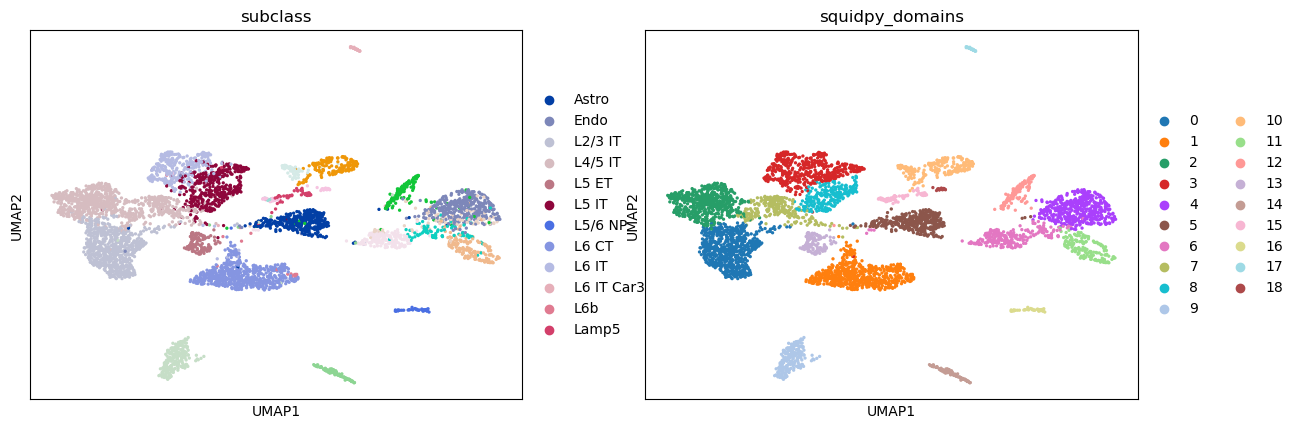

In [45]:
sc.pl.umap(ad_sp, color=["subclass", "squidpy_domains"])